In [157]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pyreadr import read_r
import numpy as np
import plotly.express as px
import janitor as jn
import statsmodels.api as sm
import sklearn as sk
import clean 


In [158]:
# Load data
ling_data = pd.read_csv('../data/lingData.txt', sep='\\s+')
ling_location = pd.read_csv('../data/lingLocation.txt', sep='\\s+')
question_data = read_r('../data/question_data.RData')

In [159]:
ling_data = clean.clean_data(ling_data)
state_df = gpd.read_file('../data/shapefiles')
state_df = state_df[state_df['iso_a2'] == 'US']  # Filter to only US

# Remove rows that are all NaN in ling_data
ling_data = ling_data.dropna(how='all')

In [ ]:
# Define region mapping for states
region_map = {
    # West Coast
    'CA': 'West Coast',
    'OR': 'West Coast',
    'WA': 'West Coast',

    # Mountain
    'AZ': 'Mountain',
    'CO': 'Mountain',
    'ID': 'Mountain',
    'MT': 'Mountain',
    'NV': 'Mountain',
    'NM': 'Mountain',
    'UT': 'Mountain',
    'WY': 'Mountain',

    # Southwest
    'TX': 'Southwest',
    'OK': 'Southwest',
    'AR': 'Southwest',
    'LA': 'Southwest',

    # South
    'AL': 'South',
    'FL': 'South',
    'GA': 'South',
    'KY': 'South',
    'MS': 'South',
    'NC': 'South',
    'SC': 'South',
    'TN': 'South',
    'VA': 'South',
    'WV': 'South',

    # Midwest
    'IL': 'Midwest',
    'IN': 'Midwest',
    'IA': 'Midwest',
    'KS': 'Midwest',
    'MI': 'Midwest',
    'MN': 'Midwest',
    'MO': 'Midwest',
    'NE': 'Midwest',
    'ND': 'Midwest',
    'OH': 'Midwest',
    'SD': 'Midwest',
    'WI': 'Midwest',

    # East Coast
    'DE': 'East Coast',
    'MD': 'East Coast',
    'NJ': 'East Coast',
    'NY': 'East Coast',
    'PA': 'East Coast',

    # New England
    'CT': 'New England',
    'ME': 'New England',
    'MA': 'New England',
    'NH': 'New England',
    'RI': 'New England',
    'VT': 'New England',

    # Non-contiguous
    'AK': 'Alaska',
    'HI': 'Hawaii'
}





In [161]:
ling_data.head()

,ID,CITY,STATE,ZIP,Q050,Q051,Q052,Q053,Q054,Q055,...,Q110,Q111,Q115,Q117,Q118,Q119,Q120,Q121,lat,long
0,1,Boise,ID,83704,4.0,1.0,3.0,2.0,3.0,1.0,...,8.0,2.0,1.0,6.0,7.0,3.0,2.0,3.0,43.631230,-116.287161
1,2,Pittsfield,MA,1201,4.0,2.0,3.0,2.0,2.0,2.0,...,8.0,2.0,1.0,1.0,7.0,1.0,1.0,3.0,42.453840,-73.254003
2,3,Burlington,VT,5401,4.0,1.0,2.0,2.0,2.0,2.0,...,4.0,2.0,1.0,4.0,7.0,1.0,2.0,1.0,44.484038,-73.221265
3,4,Easton,PA,18042,7.0,1.0,1.0,2.0,2.0,2.0,...,8.0,1.0,1.0,3.0,7.0,1.0,2.0,1.0,40.681798,-75.220820
4,5,Bedford,MA,1730,8.0,2.0,3.0,1.0,2.0,2.0,...,8.0,3.0,1.0,5.0,8.0,1.0,1.0,1.0,42.496679,-71.275046


We dont want to work with the data in this form so we will encode the data so that every column corresponds to a possible answer to a question. This will help us do PCA since we can see which lexical features are the most important

In [162]:
q_cols = [c for c in ling_data.columns if c.startswith("Q")]

# Perform One-Hot Encoding
binary_df = pd.get_dummies(ling_data[q_cols], columns=q_cols, dtype=int)

# Drop columns representing unanswered questions
zero_cols = [c for c in binary_df.columns if c.endswith("_0")]
binary_df = binary_df.drop(columns=zero_cols)

# Combine back with location metadata
metadata_cols = ["ID", "CITY", "STATE", "ZIP", "lat", "long"]
ling_data = pd.concat([ling_data[metadata_cols], binary_df], axis=1)

In [163]:
ling_data.head()

,ID,CITY,STATE,ZIP,lat,long,Q050_1.0,Q050_2.0,Q050_3.0,Q050_4.0,...,Q120_4.0,Q120_5.0,Q120_6.0,Q121_1.0,Q121_2.0,Q121_3.0,Q121_4.0,Q121_5.0,Q121_6.0,Q121_7.0
0,1,Boise,ID,83704,43.631230,-116.287161,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,2,Pittsfield,MA,1201,42.453840,-73.254003,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2,3,Burlington,VT,5401,44.484038,-73.221265,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
3,4,Easton,PA,18042,40.681798,-75.220820,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,5,Bedford,MA,1730,42.496679,-71.275046,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [164]:
# Bin the data by latitude and longitude, rounding lat and long to nearest degree
ling_data['lat_bin'] = ling_data['lat'].round()
ling_data['long_bin'] = ling_data['long'].round()

# Columns that contain the encoded linguistic responses
response_cols = [
    col for col in ling_data.columns
    if col not in metadata_cols + ['lat_bin', 'long_bin']
]

# Get the most common state within each geographic bin
cell_state = (
    ling_data
    .groupby(['lat_bin', 'long_bin'])['STATE']
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

# Sum responses within each geographic bin
ling_location = (
    ling_data
    .groupby(['lat_bin', 'long_bin'])[response_cols]
    .sum()
    .reset_index()
)

# Add state back to the geographic data
ling_location = ling_location.merge(
    cell_state,
    on=['lat_bin', 'long_bin'],
    how='left'
)



In [165]:
ling_data.head()


,ID,CITY,STATE,ZIP,lat,long,Q050_1.0,Q050_2.0,Q050_3.0,Q050_4.0,...,Q120_6.0,Q121_1.0,Q121_2.0,Q121_3.0,Q121_4.0,Q121_5.0,Q121_6.0,Q121_7.0,lat_bin,long_bin
0,1,Boise,ID,83704,43.631230,-116.287161,0,0,0,1,...,0,0,0,1,0,0,0,0,44.0,-116.0
1,2,Pittsfield,MA,1201,42.453840,-73.254003,0,0,0,1,...,0,0,0,1,0,0,0,0,42.0,-73.0
2,3,Burlington,VT,5401,44.484038,-73.221265,0,0,0,1,...,0,1,0,0,0,0,0,0,44.0,-73.0
3,4,Easton,PA,18042,40.681798,-75.220820,0,0,0,0,...,0,1,0,0,0,0,0,0,41.0,-75.0
4,5,Bedford,MA,1730,42.496679,-71.275046,0,0,0,0,...,0,1,0,0,0,0,0,0,42.0,-71.0


In [166]:

ling_data = ling_data.merge(
    ling_data.groupby(['lat_bin', 'long_bin'])[response_cols].sum().sum(axis=1).reset_index(name='total_responses'),
    on=['lat_bin', 'long_bin']
)

In [167]:
# Divide by the total number of responses in each bin to get proportions
df = ling_data.copy()
# Divide by the total number of responses in each bin to get proportions
df[response_cols] = df[response_cols].div(df['total_responses'], axis=0)


In [168]:
df.head()

,ID,CITY,STATE,ZIP,lat,long,Q050_1.0,Q050_2.0,Q050_3.0,Q050_4.0,...,Q121_1.0,Q121_2.0,Q121_3.0,Q121_4.0,Q121_5.0,Q121_6.0,Q121_7.0,lat_bin,long_bin,total_responses
0,1,Boise,ID,83704,43.631230,-116.287161,0.0,0.0,0.0,0.000227,...,0.000000,0.0,0.000227,0.0,0.0,0.0,0.0,44.0,-116.0,4400
1,2,Pittsfield,MA,1201,42.453840,-73.254003,0.0,0.0,0.0,0.000025,...,0.000000,0.0,0.000025,0.0,0.0,0.0,0.0,42.0,-73.0,39297
2,3,Burlington,VT,5401,44.484038,-73.221265,0.0,0.0,0.0,0.000201,...,0.000201,0.0,0.000000,0.0,0.0,0.0,0.0,44.0,-73.0,4966
3,4,Easton,PA,18042,40.681798,-75.220820,0.0,0.0,0.0,0.000000,...,0.000061,0.0,0.000000,0.0,0.0,0.0,0.0,41.0,-75.0,16456
4,5,Bedford,MA,1730,42.496679,-71.275046,0.0,0.0,0.0,0.000000,...,0.000016,0.0,0.000000,0.0,0.0,0.0,0.0,42.0,-71.0,61697


In [169]:
metadata_cols = ["ID", "CITY", "STATE", "ZIP", "lat", "long", "lat_bin", "long_bin", "total_responses"]

# PCA


# No Mean Centering

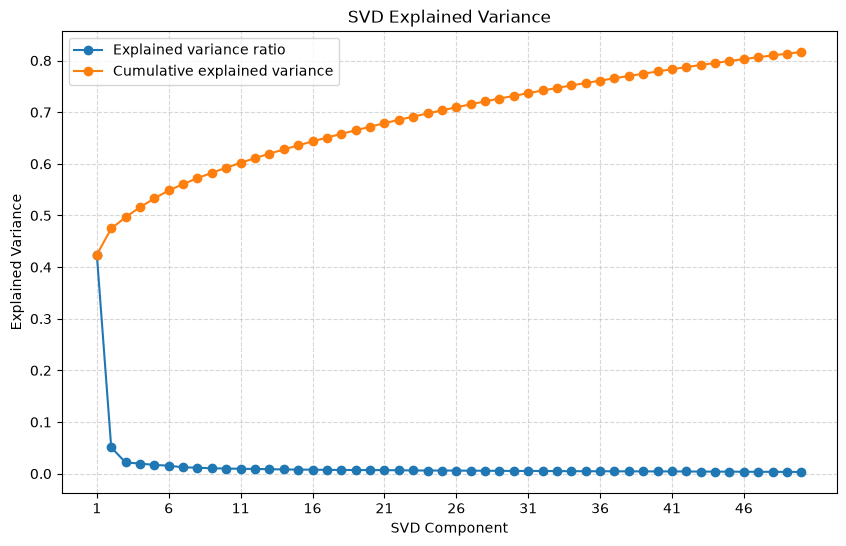

In [170]:
# Perform SVD
svd = sk.decomposition.TruncatedSVD(
    n_components=50,
    random_state=47
)

svd_uncentered= svd.fit_transform(
    df.drop(columns=metadata_cols)
)

# Explained variance
variance_ratio_svd = svd.explained_variance_ratio_
cumulative_variance_svd = np.cumsum(variance_ratio_svd)

# Plot explained variance and cumulative variance
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 51),
    variance_ratio_svd,
    marker='o',
    linestyle='-',
    label='Explained variance ratio'
)

plt.plot(
    range(1, 51),
    cumulative_variance_svd,
    marker='o',
    linestyle='-',
    label='Cumulative explained variance'
)

plt.xlabel('SVD Component')
plt.ylabel('Explained Variance')
plt.title('SVD Explained Variance')
plt.xticks(range(1, 51,5))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Save plot 
plt.savefig('../figs/svd_explained_variance.png', dpi=300, bbox_inches='tight')




In [171]:
# Make dataframe with svd scores and lat/long for plotting
svd_df = pd.DataFrame(
    svd_uncentered,
    columns=[
        f'SVD_{i+1}'
        for i in range(svd_uncentered.shape[1])
    ]
)

svd_df['lat'] = df['lat_bin'].values
svd_df['long'] = df['long_bin'].values
svd_df['Region'] = df['STATE'].map(region_map)
svd_df['STATE'] = df['STATE']


In [172]:
svd_df.head()

,SVD_1,SVD_2,SVD_3,SVD_4,SVD_5,SVD_6,SVD_7,SVD_8,SVD_9,SVD_10,...,SVD_45,SVD_46,SVD_47,SVD_48,SVD_49,SVD_50,lat,long,Region,STATE
0,0.001153,-0.000008,0.000223,0.000127,0.000148,0.000394,-0.000232,0.000063,-0.000147,-0.000199,...,0.000009,-3.499861e-05,-0.000053,0.000126,0.000007,0.000063,44.0,-116.0,Mountain,ID
1,0.000145,-0.000009,-0.000010,-0.000035,0.000034,-0.000010,0.000020,-0.000009,-0.000007,-0.000019,...,0.000018,-3.146276e-07,0.000004,-0.000006,0.000017,0.000010,42.0,-73.0,New England,MA
2,0.001095,-0.000046,-0.000006,-0.000097,0.000435,-0.000126,0.000018,0.000056,-0.000264,0.000226,...,0.000040,6.167454e-06,0.000070,0.000093,-0.000081,0.000083,44.0,-73.0,New England,VT
3,0.000316,-0.000007,-0.000074,-0.000021,0.000109,0.000021,-0.000083,0.000003,0.000009,-0.000049,...,0.000011,1.678918e-05,0.000006,-0.000024,0.000021,0.000006,41.0,-75.0,East Coast,PA
4,0.000084,0.000002,-0.000020,-0.000026,0.000017,-0.000011,-0.000005,0.000008,-0.000018,-0.000013,...,0.000007,2.260921e-06,0.000006,-0.000003,0.000001,-0.000009,42.0,-71.0,New England,MA


Text(0.5, 1.0, 'Projection of Data onto First Two SVD Components')

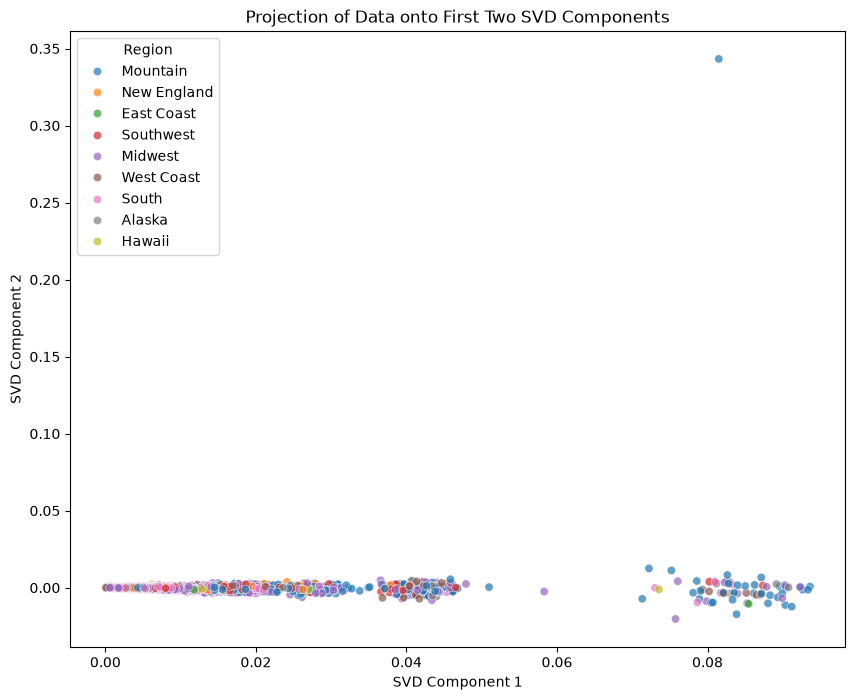

In [173]:
# Plot project of data onto first two SVD components
plt.figure(figsize=(10, 8))


sns.scatterplot(
    data=svd_df,
    x='SVD_1',
    y='SVD_2',
    hue='Region',
    palette='tab10',
    alpha=0.7
)

plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.title('Projection of Data onto First Two SVD Components')


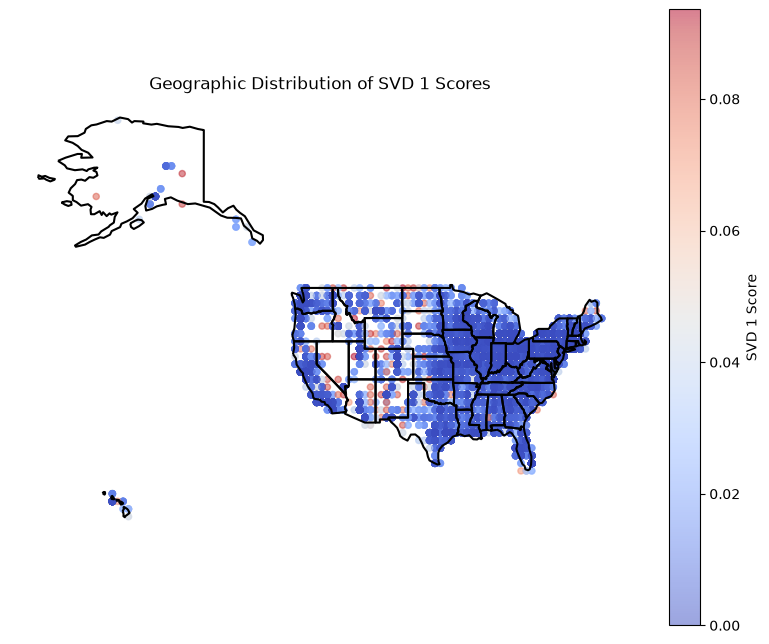

In [174]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    svd_df['long'],
    svd_df['lat'],
    c=svd_df['SVD_1'],
    cmap='coolwarm',
    s=20,
    alpha=0.5
)

# Add state boundaries
state_gdf = gpd.GeoDataFrame(state_df)
state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black'
)

# Add colorbar
plt.colorbar(
    scatter,
    label='SVD 1 Score'
)

plt.axis('off')
plt.title('Geographic Distribution of SVD 1 Scores')

plt.show()

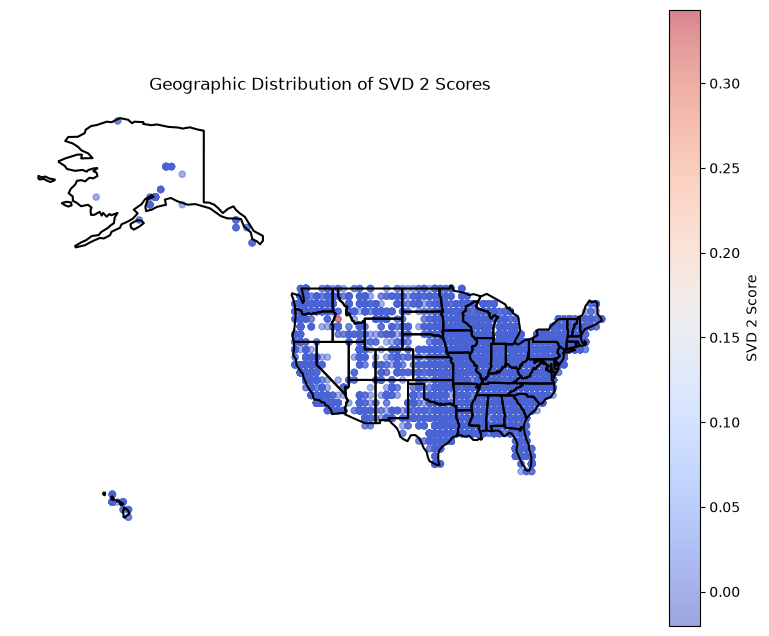

In [175]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    svd_df['long'],
    svd_df['lat'],
    c=svd_df['SVD_2'],
    cmap='coolwarm',
    s=20,
    alpha=0.5
)

# Add state boundaries
state_gdf = gpd.GeoDataFrame(state_df)
state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black'
)

# Add colorbar
plt.colorbar(
    scatter,
    label='SVD 2 Score'
)

plt.axis('off')
plt.title('Geographic Distribution of SVD 2 Scores')

plt.show()

Now we put them together

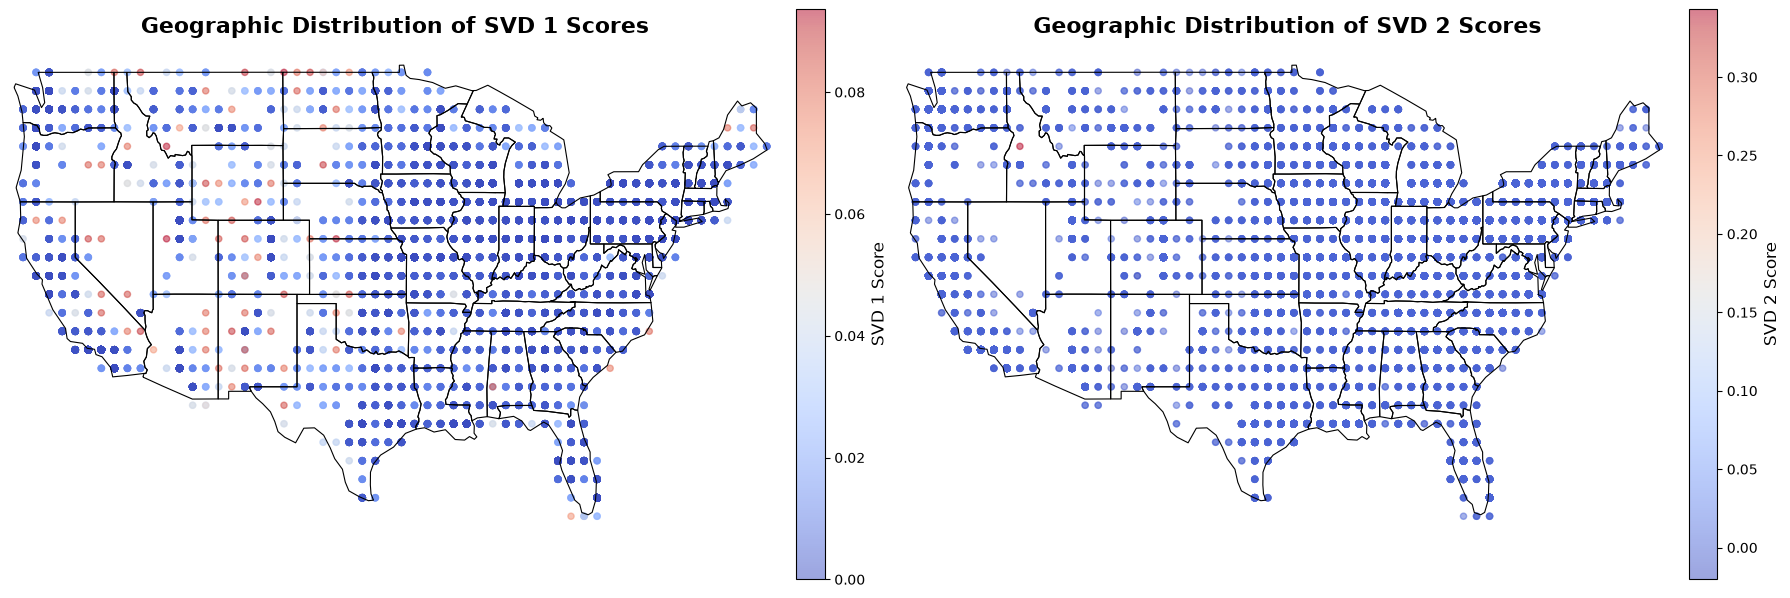

In [176]:


# 1. Filter out Alaska and Hawaii from point data (Lower 48 bounding box)
svd_df_lower48 = svd_df[
    (svd_df["lat"] >= 24) & (svd_df["lat"] <= 50) &
    (svd_df["long"] >= -125) & (svd_df["long"] <= -66)
].copy()

# 2. Filter out Alaska and Hawaii from state boundaries
state_gdf = gpd.GeoDataFrame(state_df)
if "NAME" in state_gdf.columns:
    state_gdf = state_gdf[~state_gdf["NAME"].isin(["Alaska", "Hawaii"])]
elif "STUSPS" in state_gdf.columns:
    state_gdf = state_gdf[~state_gdf["STUSPS"].isin(["AK", "HI"])]

# 3. Create a 1-row, 2-column subplot grid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- LEFT SUBPLOT: SVD 1 ---
# Plot state boundaries
state_gdf.boundary.plot(ax=ax1, color='black', linewidth=0.8)

# Plot scatter points for SVD 1
scatter1 = ax1.scatter(
    svd_df_lower48['long'],
    svd_df_lower48['lat'],
    c=svd_df_lower48['SVD_1'],
    cmap='coolwarm',
    s=20,
    alpha=0.5
)

# Lock map boundaries and remove axis
ax1.set_xlim(-125, -66)
ax1.set_ylim(24, 50)
ax1.axis('off')
ax1.set_title('Geographic Distribution of SVD 1 Scores', fontsize=16, fontweight='bold', pad=15)

# Add colorbar for SVD 1
cbar1 = fig.colorbar(scatter1, ax=ax1, fraction=0.035, pad=0.02)
cbar1.set_label('SVD 1 Score', fontsize=12)

# --- RIGHT SUBPLOT: SVD 2 ---
# Plot state boundaries
state_gdf.boundary.plot(ax=ax2, color='black', linewidth=0.8)

# Plot scatter points for SVD 2
scatter2 = ax2.scatter(
    svd_df_lower48['long'],
    svd_df_lower48['lat'],
    c=svd_df_lower48['SVD_2'],
    cmap='coolwarm',
    s=20,
    alpha=0.5
)

# Lock map boundaries and remove axis
ax2.set_xlim(-125, -66)
ax2.set_ylim(24, 50)
ax2.axis('off')
ax2.set_title('Geographic Distribution of SVD 2 Scores', fontsize=16, fontweight='bold', pad=15)

# Add colorbar for SVD 2
cbar2 = fig.colorbar(scatter2, ax=ax2, fraction=0.035, pad=0.02)
cbar2.set_label('SVD 2 Score', fontsize=12)

# Adjust overall layout
plt.tight_layout()
# Save plot
plt.savefig('../figs/svd_geographic_distribution.png', dpi=300, bbox_inches='tight')

In [177]:
# t-SNE
tsne= sk.manifold.TSNE(
    n_components=2,
    perplexity=30,
    random_state=47,
    init='pca'
)

svd_tsne = tsne.fit_transform(svd_df.drop(columns=['lat', 'long', 'Region','STATE']))


In [178]:
tsne_df = pd.DataFrame(
    svd_tsne,
    columns=['tSNE_1', 'tSNE_2']
)


tsne_df['Region'] = df['STATE'].map(region_map)
tsne_df['lat'] = df['lat_bin'].values
tsne_df['long'] = df['long_bin'].values

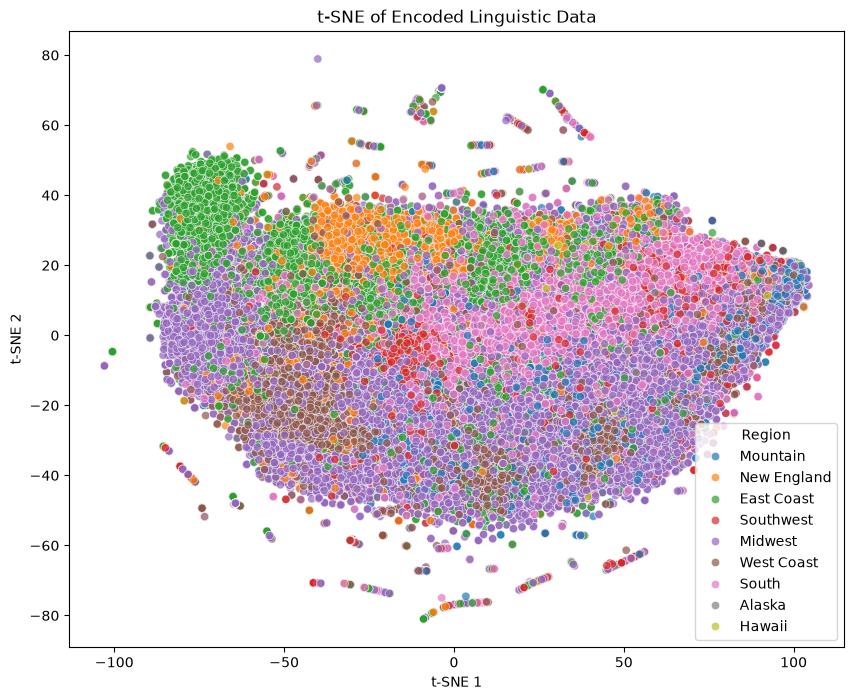

In [179]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=tsne_df,
    x='tSNE_1',
    y='tSNE_2',
    hue='Region',
    palette='tab10',
    alpha=0.7
)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE of Encoded Linguistic Data')

plt.show()

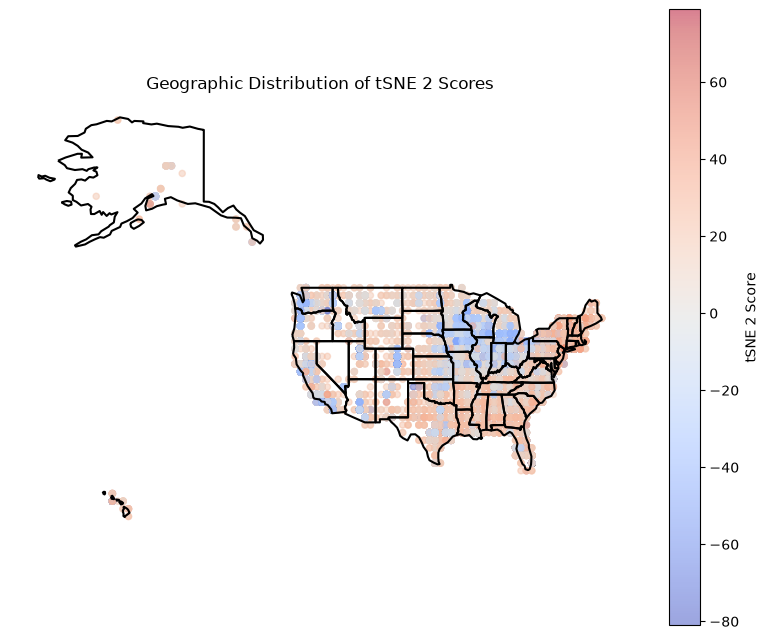

In [180]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    tsne_df['long'],
    tsne_df['lat'],
    c=tsne_df['tSNE_2'],
    cmap='coolwarm',
    s=20,
    alpha=0.5
)

# Add state boundaries
state_gdf = gpd.GeoDataFrame(state_df)
state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black'
)

# Add colorbar
plt.colorbar(
    scatter,
    label='tSNE 2 Score'
)

plt.axis('off')
plt.title('Geographic Distribution of tSNE 2 Scores')

plt.show()

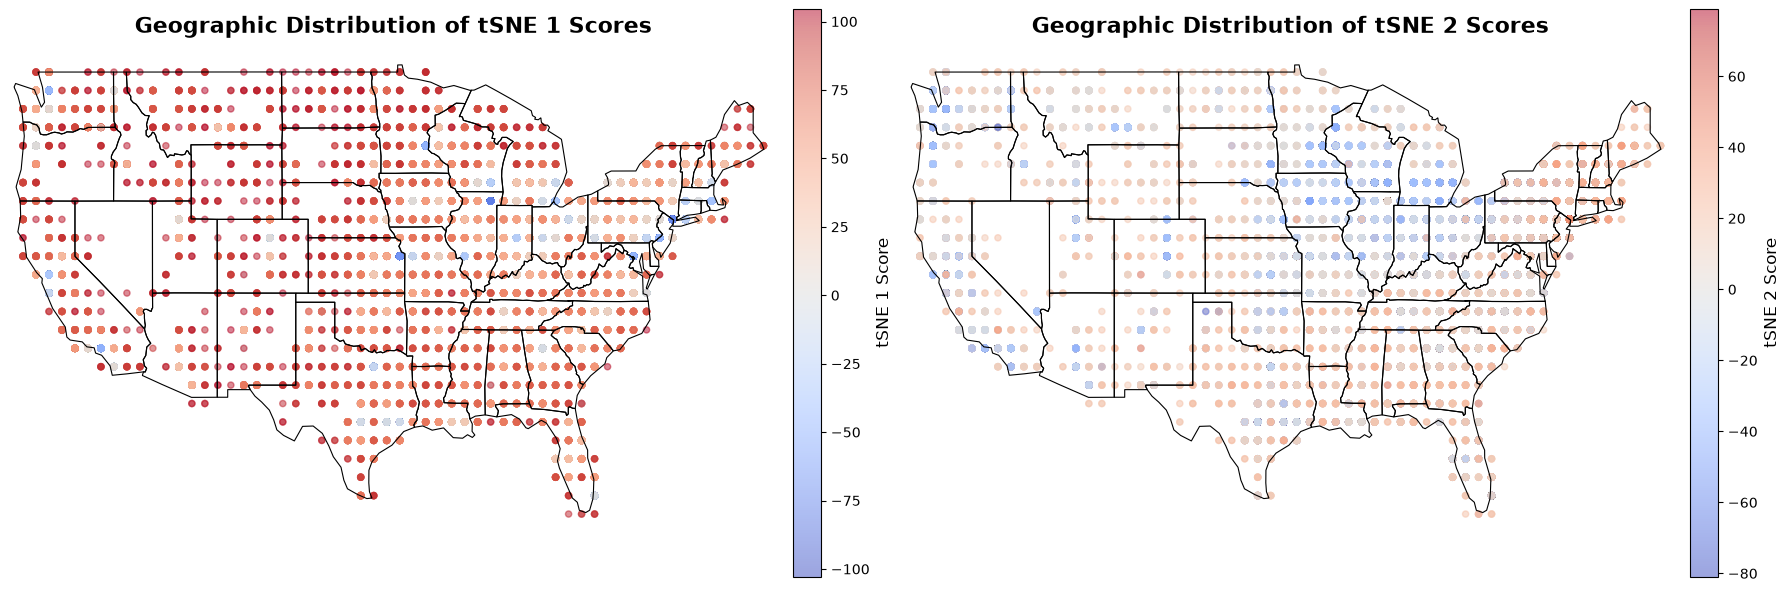

In [181]:


# 1. Filter out Alaska and Hawaii from point data (Lower 48 bounding box)
tsne_df_lower48 = tsne_df[
    (tsne_df["lat"] >= 24) & (tsne_df["lat"] <= 50) &
    (tsne_df["long"] >= -125) & (tsne_df["long"] <= -66)
].copy()

# 2. Filter out Alaska and Hawaii from state boundaries
state_gdf = gpd.GeoDataFrame(state_df)
if "NAME" in state_gdf.columns:
    state_gdf = state_gdf[~state_gdf["NAME"].isin(["Alaska", "Hawaii"])]
elif "STUSPS" in state_gdf.columns:
    state_gdf = state_gdf[~state_gdf["STUSPS"].isin(["AK", "HI"])]

# 3. Create a 1-row, 2-column subplot grid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- LEFT SUBPLOT: tSNE 1 ---
# Plot state boundaries
state_gdf.boundary.plot(ax=ax1, color='black', linewidth=0.8)

# Plot scatter points for tSNE 1
scatter1 = ax1.scatter(
    tsne_df_lower48['long'],
    tsne_df_lower48['lat'],
    c=tsne_df_lower48['tSNE_1'],
    cmap='coolwarm',
    s=20,
    alpha=0.5
)

# Lock map boundaries and remove axis
ax1.set_xlim(-125, -66)
ax1.set_ylim(24, 50)
ax1.axis('off')
ax1.set_title('Geographic Distribution of tSNE 1 Scores', fontsize=16, fontweight='bold', pad=15)

# Add colorbar for tSNE 1
cbar1 = fig.colorbar(scatter1, ax=ax1, fraction=0.035, pad=0.02)
cbar1.set_label('tSNE 1 Score', fontsize=12)

# --- RIGHT SUBPLOT: tSNE 2 ---
# Plot state boundaries
state_gdf.boundary.plot(ax=ax2, color='black', linewidth=0.8)

# Plot scatter points for tSNE 2
scatter2 = ax2.scatter(
    tsne_df_lower48['long'],
    tsne_df_lower48['lat'],
    c=tsne_df_lower48['tSNE_2'],
    cmap='coolwarm',
    s=20,
    alpha=0.5
)

# Lock map boundaries and remove axis
ax2.set_xlim(-125, -66)
ax2.set_ylim(24, 50)
ax2.axis('off')
ax2.set_title('Geographic Distribution of tSNE 2 Scores', fontsize=16, fontweight='bold', pad=15)

# Add colorbar for tSNE 2
cbar2 = fig.colorbar(scatter2, ax=ax2, fraction=0.035, pad=0.02)
cbar2.set_label('tSNE 2 Score', fontsize=12)

# Adjust overall layout
plt.tight_layout()
# Save plot
plt.savefig('../figs/tsne_geographic_distribution.png', dpi=300, bbox_inches='tight')

# Mean centered

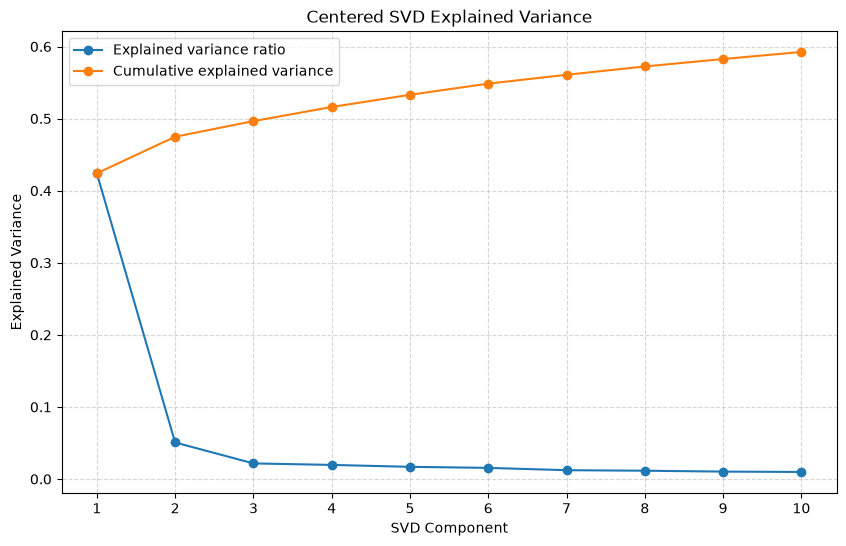

In [182]:
# Mean centered SVD
df_centered = df.drop(columns=metadata_cols) - df.drop(columns=metadata_cols).mean()

svd_centered = sk.decomposition.TruncatedSVD(
    n_components=10,
    random_state=47
)       

df_centered_svd = svd_centered.fit_transform(
    df_centered
)


# Explained variance
variance_ratio_svd_centered = svd_centered.explained_variance_ratio_
cumulative_variance_svd_centered = np.cumsum(variance_ratio_svd_centered)   

# Plot explained variance and cumulative variance
# Plot explained variance and cumulative variance
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 11),
    variance_ratio_svd_centered,
    marker='o',
    linestyle='-',
    label='Explained variance ratio'
)

plt.plot(
    range(1, 11),
    cumulative_variance_svd_centered,
    marker='o',
    linestyle='-',
    label='Cumulative explained variance'
)

plt.xlabel('SVD Component')
plt.ylabel('Explained Variance')
plt.title('Centered SVD Explained Variance')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()



In [183]:
# 
# Make dataframe with svd scores and lat/long for plotting
svd_centered_df = pd.DataFrame(
    df_centered_svd,
    columns=[
        f'SVD_{i+1}'
        for i in range(df_centered_svd.shape[1])
    ]
)

svd_centered_df['lat'] = df['lat'].values
svd_centered_df['long'] = df['long'].values
svd_centered_df['Region'] = df['STATE'].map(region_map)

Text(0.5, 1.0, 'Projection of Data onto First Two SVD Components')

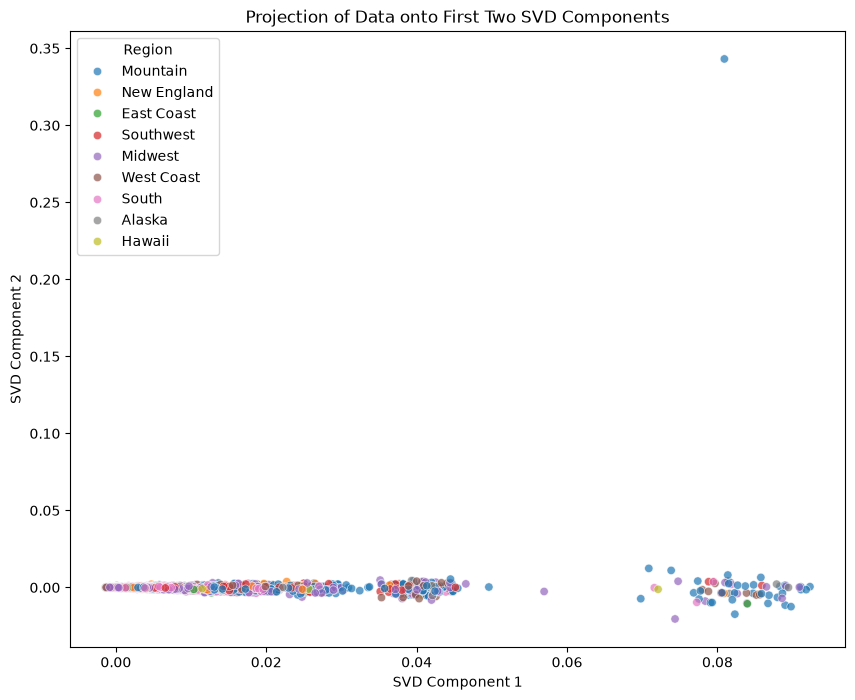

In [184]:
# Plot project of data onto first two SVD components
plt.figure(figsize=(10, 8))


sns.scatterplot(
    data=svd_centered_df,
    x='SVD_1',
    y='SVD_2',
    hue='Region',
    palette='tab10',
    alpha=0.7
)

plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.title('Projection of Data onto First Two SVD Components')


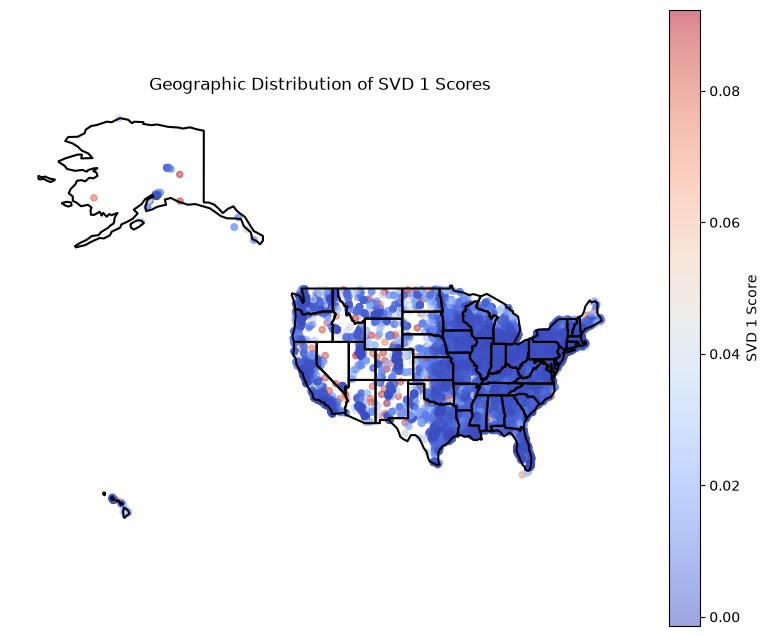

In [185]:
# Map
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    svd_centered_df['long'],
    svd_centered_df['lat'],
    c=svd_centered_df['SVD_1'],
    cmap='coolwarm',
    s=20,
    alpha=0.5
)

# Add state boundaries
state_gdf = gpd.GeoDataFrame(state_df)
state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black'
)

# Add colorbar
plt.colorbar(
    scatter,
    label='SVD 1 Score'
)

plt.axis('off')
plt.title('Geographic Distribution of SVD 1 Scores')

plt.show()

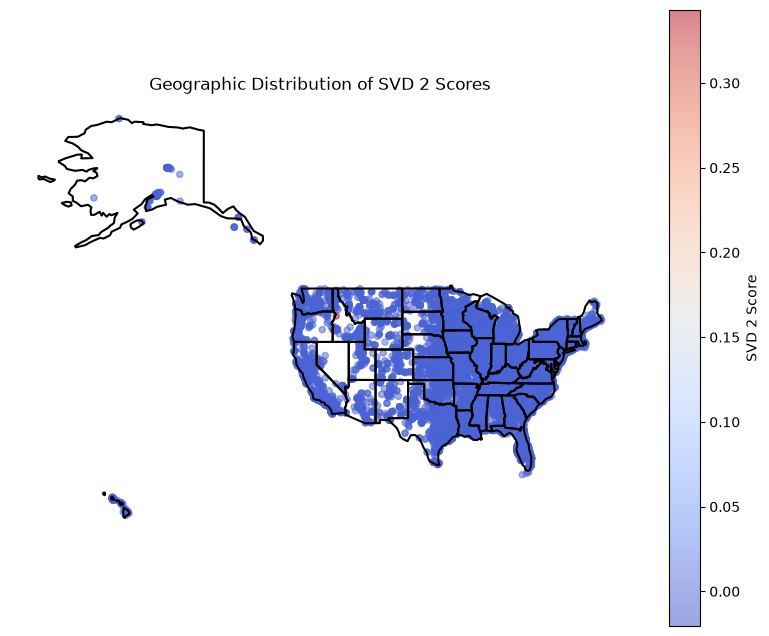

In [186]:
# Map
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    svd_centered_df['long'],
    svd_centered_df['lat'],
    c=svd_centered_df['SVD_2'],
    cmap='coolwarm',
    s=20,
    alpha=0.5
)

# Add state boundaries
state_gdf = gpd.GeoDataFrame(state_df)
state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black'
)

# Add colorbar
plt.colorbar(
    scatter,
    label='SVD 2 Score'
)

plt.axis('off')
plt.title('Geographic Distribution of SVD 2 Scores')

plt.show()

In [ ]:
tsne_centered_df = pd.DataFrame(
    svd_centered_tsne,
    columns=['tSNE_1', 'tSNE_2']
)


tsne_centered_df['Region'] = df['STATE'].map(region_map)
tsne_centered_df['lat'] = df['lat_bin'].values
tsne_centered_df['long'] = df['long_bin'].values

Text(0.5, 1.0, 'Projection of Data onto First Two SVD Components')

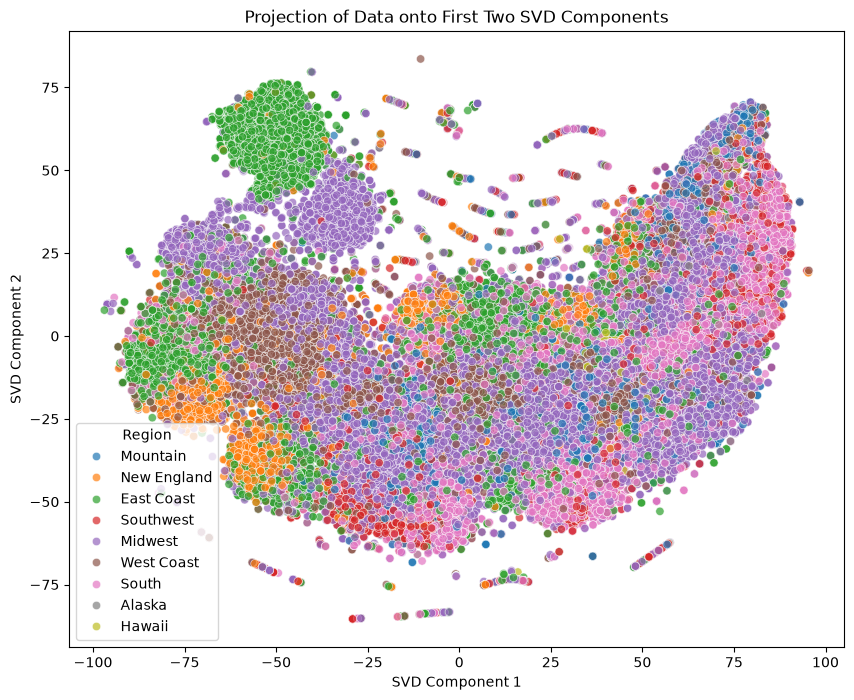

In [ ]:
# Plot project of data onto first two SVD components
plt.figure(figsize=(10, 8))


sns.scatterplot(
    data=tsne_centered_df,
    x='tSNE_1',
    y='tSNE_2',
    hue='Region',
    palette='tab10',
    alpha=0.7
)

plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.title('Projection of Data onto First Two SVD Components')


# With mean centering and scaling (Just PCA)

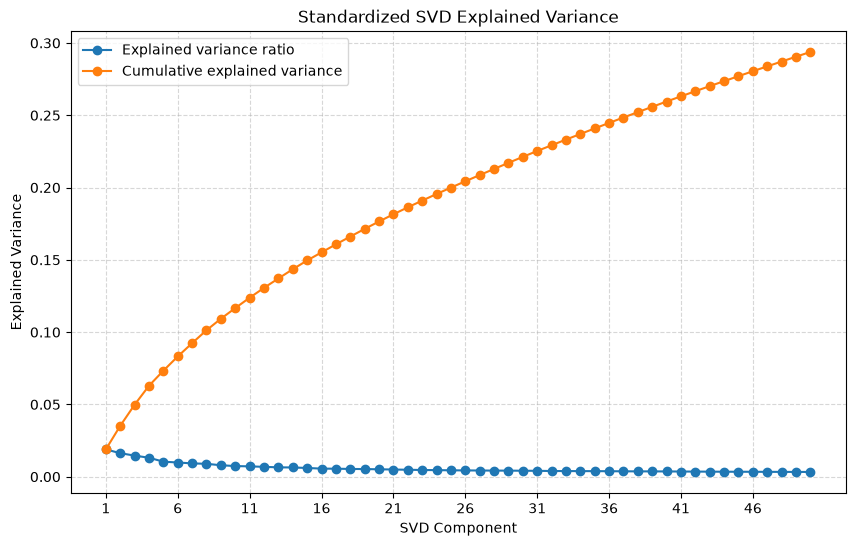

In [ ]:
# PCA with mean centering and no scaling

df_standardized = (df.drop(columns=metadata_cols) - df.drop(columns=metadata_cols).mean())/ df.drop(columns=metadata_cols).std()

pca = sk.decomposition.PCA(
    n_components=50,
    random_state=47
)       



df_standardized_pca = pca.fit_transform(
    df_standardized
)


# Explained variance
variance_ratio_svd_standardized = pca.explained_variance_ratio_
cumulative_variance_svd_standardized = np.cumsum(variance_ratio_svd_standardized)   

# Plot explained variance and cumulative variance
# Plot explained variance and cumulative variance
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 51),
    variance_ratio_svd_standardized,
    marker='o',
    linestyle='-',
    label='Explained variance ratio'
)

plt.plot(
    range(1, 51),
    cumulative_variance_svd_standardized,
    marker='o',
    linestyle='-',
    label='Cumulative explained variance'
)

plt.xlabel('SVD Component')
plt.ylabel('Explained Variance')
plt.title('Standardized SVD Explained Variance')
plt.xticks(range(1, 51, 5))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Save plot
plt.savefig('../figs/pcaexplained_variance.png', dpi=300)


In [ ]:
# Make dataframe with svd scores and lat/long for plotting
df_standardized_pca = pd.DataFrame(
    df_standardized_pca,
    columns=[
        f'SVD_{i+1}'
        for i in range(df_standardized_pca.shape[1])
    ]
)

df_standardized_pca['lat'] = df['lat'].values
df_standardized_pca['long'] = df['long'].values
df_standardized_pca['Region'] = df['STATE'].map(region_map)

<Axes: xlabel='SVD_1', ylabel='SVD_2'>

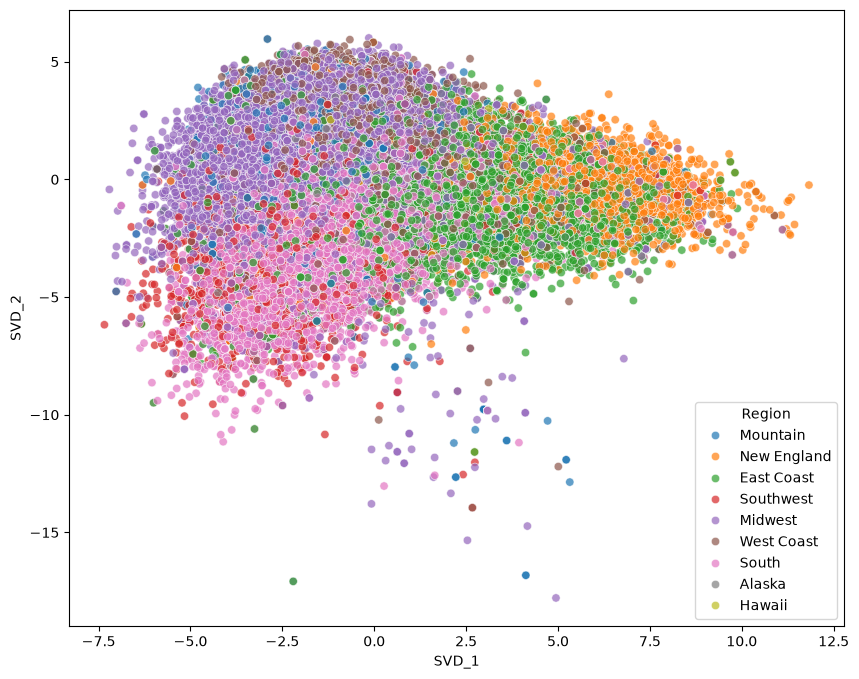

In [ ]:
# Plot project of data onto first two SVD components
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_standardized_pca,
    x='SVD_1',
    y='SVD_2',
    hue='Region',
    palette='tab10',
    alpha=0.7
)


In [ ]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    df_standardized_pca['long'],
    df_standardized_pca['lat'],
    c=df_standardized_pca['PC1'],
    cmap='coolwarm',
    s=20,
    alpha=0.5
)

# Add state boundaries
state_gdf = gpd.GeoDataFrame(state_df)
state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black'
)

# Add colorbar
plt.colorbar(
    scatter,
    label='PC 1 Score'
)

plt.axis('off')
plt.title('Geographic Distribution of PC 2 Scores')

plt.show()

NameError: name 'svd_standardized_df' is not defined

<Figure size 1000x800 with 0 Axes>

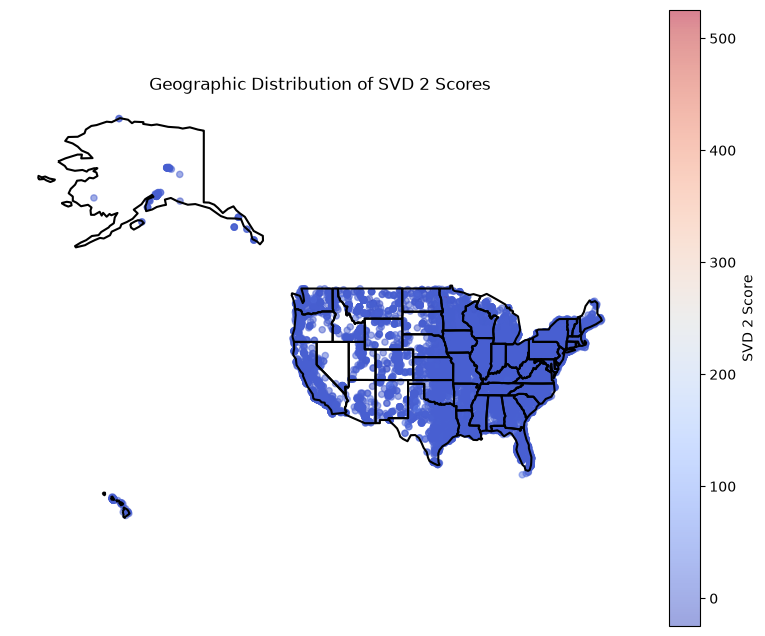

In [ ]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    df_standardized_pca['long'],
    df_standardized_pca['lat'],
    c=df_standardized_pca['PC2'],
    cmap='coolwarm',
    s=20,
    alpha=0.5
)

# Add state boundaries
state_gdf = gpd.GeoDataFrame(state_df)
state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black'
)

# Add colorbar
plt.colorbar(
    scatter,
    label='SVD 2 Score'
)

plt.axis('off')
plt.title('Geographic Distribution of SVD 2 Scores')

plt.show()

In [ ]:
df_standardized_pca_tsne = tsne.fit_transform(df_standardized_pca.drop(columns=['lat', 'long', 'Region']))

In [ ]:
tsne_standardized_df = pd.DataFrame(
    df_standardized_pca_tsne,
    columns=['tSNE_1', 'tSNE_2']
)



tsne_standardized_df['Region'] = df['STATE'].map(region_map)
tsne_standardized_df['lat'] = df['lat_bin'].values
tsne_standardized_df['long'] = df['long_bin'].values

NameError: name 'svd_standardized_df_tsne' is not defined

Text(0.5, 1.0, 'Projection of Data onto First Two SVD Components')

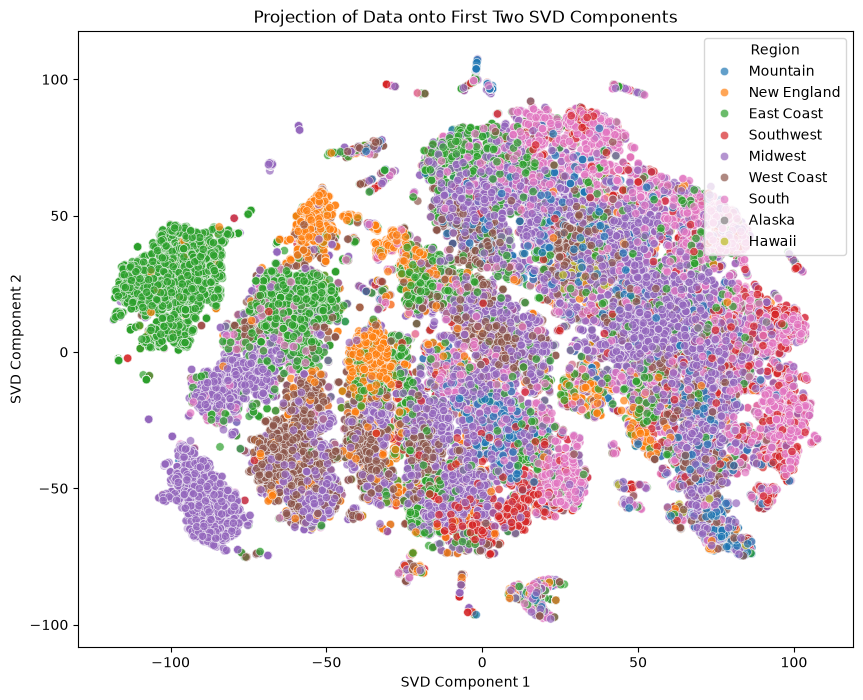

In [ ]:
# Plot project of data onto first two SVD components
plt.figure(figsize=(10, 8))


sns.scatterplot(
    data=tsne_standardized_df,
    x='tSNE_1',
    y='tSNE_2',
    hue='Region',
    palette='tab10',
    alpha=0.7
)

plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.title('Projection of Data onto First Two SVD Components')


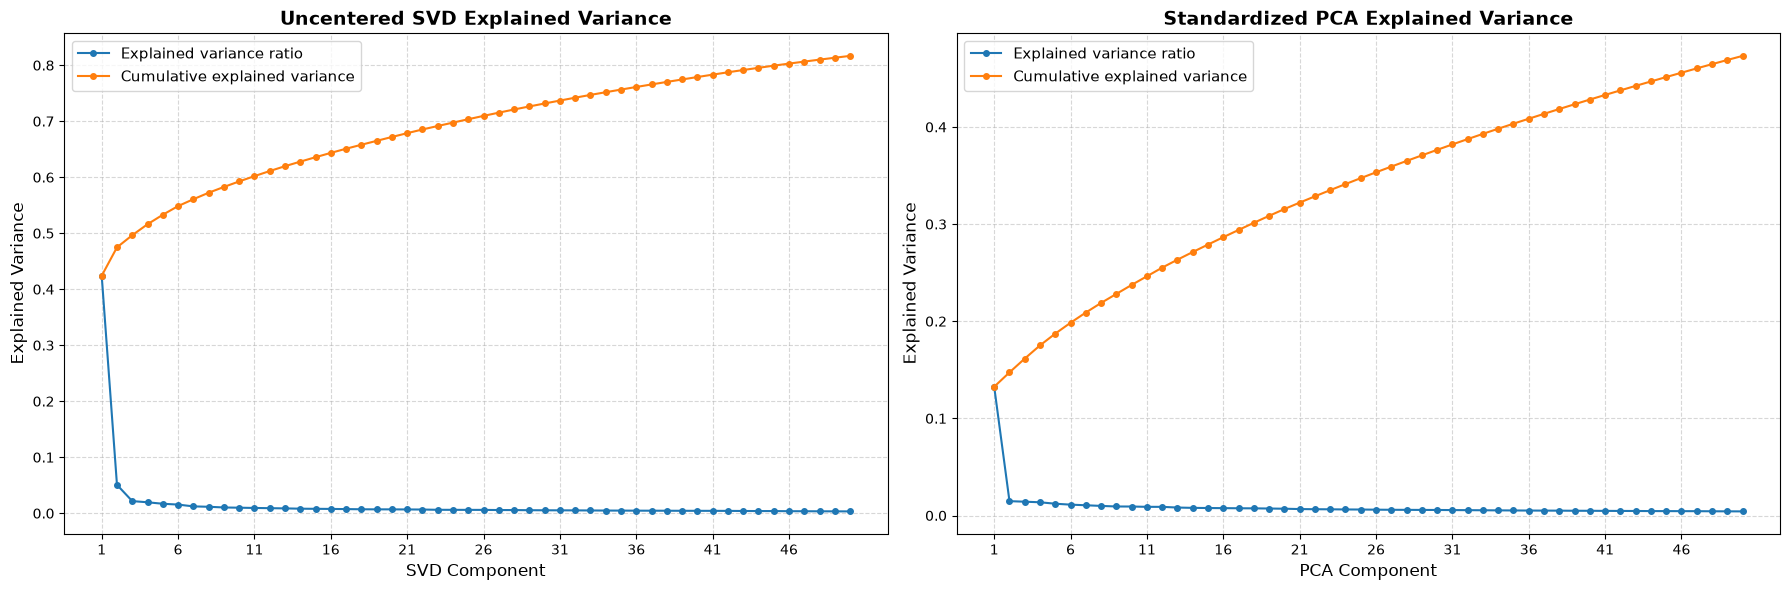

In [ ]:
# Put togther skree plots from both vairbales 

# Separate numeric data from metadata
data = df.drop(columns=metadata_cols)


svd = sk.decomposition.TruncatedSVD(n_components=50, random_state=47)
svd_uncentered = svd.fit_transform(data)

var_ratio_svd = svd.explained_variance_ratio_
cum_var_svd = np.cumsum(var_ratio_svd)

df_standardized = (data - data.mean()) / data.std()

pca = sk.decomposition.PCA(n_components=50, random_state=47)
df_standardized_pca = pca.fit_transform(df_standardized)

var_ratio_pca = pca.explained_variance_ratio_
cum_var_pca = np.cumsum(var_ratio_pca)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- LEFT SUBPLOT: Uncentered SVD ---
ax1.plot(
    range(1, 51),
    var_ratio_svd,
    marker='o',
    markersize=4,
    linestyle='-',
    label='Explained variance ratio'
)
ax1.plot(
    range(1, 51),
    cum_var_svd,
    marker='o',
    markersize=4,
    linestyle='-',
    label='Cumulative explained variance'
)
ax1.set_xlabel('SVD Component', fontsize=12)
ax1.set_ylabel('Explained Variance', fontsize=12)
ax1.set_title('Uncentered SVD Explained Variance', fontsize=14, fontweight='bold')
ax1.set_xticks(range(1, 51, 5))
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=11)

# --- RIGHT SUBPLOT: Standardized PCA ---
ax2.plot(
    range(1, 51),
    var_ratio_pca,
    marker='o',
    markersize=4,
    linestyle='-',
    label='Explained variance ratio'
)
ax2.plot(
    range(1, 51),
    cum_var_pca,
    marker='o',
    markersize=4,
    linestyle='-',
    label='Cumulative explained variance'
)
ax2.set_xlabel('PCA Component', fontsize=12)
ax2.set_ylabel('Explained Variance', fontsize=12)
ax2.set_title('Standardized PCA Explained Variance', fontsize=14, fontweight='bold')
ax2.set_xticks(range(1, 51, 5))
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=11)

plt.tight_layout()

# Save combined plot
plt.savefig('../figs/svd_vs_pca_explained_variance.png', dpi=300, bbox_inches='tight')
plt.show()

# Clustering

## K-means

<Axes: xlabel='long', ylabel='lat'>

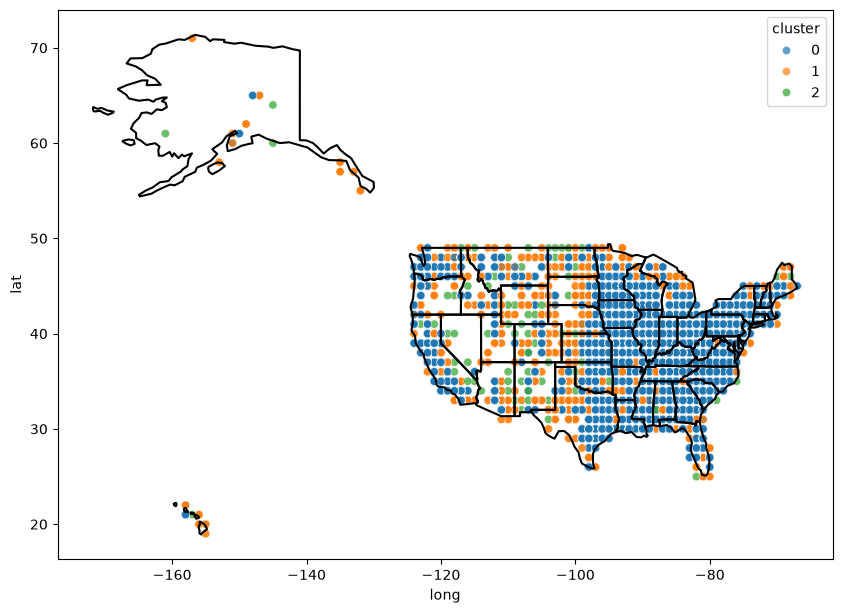

In [188]:
# Perform k-means using non-standarized svd scores

kmeans = sk.cluster.KMeans(n_clusters= 3, random_state=47)

kmeans.fit(svd_df.drop(columns=['lat', 'long', 'Region', 'STATE']))

# Add cluster labels to the svd_df and plot on map
k_means_df = svd_df.copy()
k_means_df['cluster'] = kmeans.labels_

# Plot the clusters on a map
plt.figure(figsize=(10, 8))

scatter = sns.scatterplot(
    data=k_means_df,
    x='long',
    y='lat',
    hue='cluster',
    palette='tab10',
    alpha=0.7
)
state_gdf = gpd.GeoDataFrame(state_df)
state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black'
)   


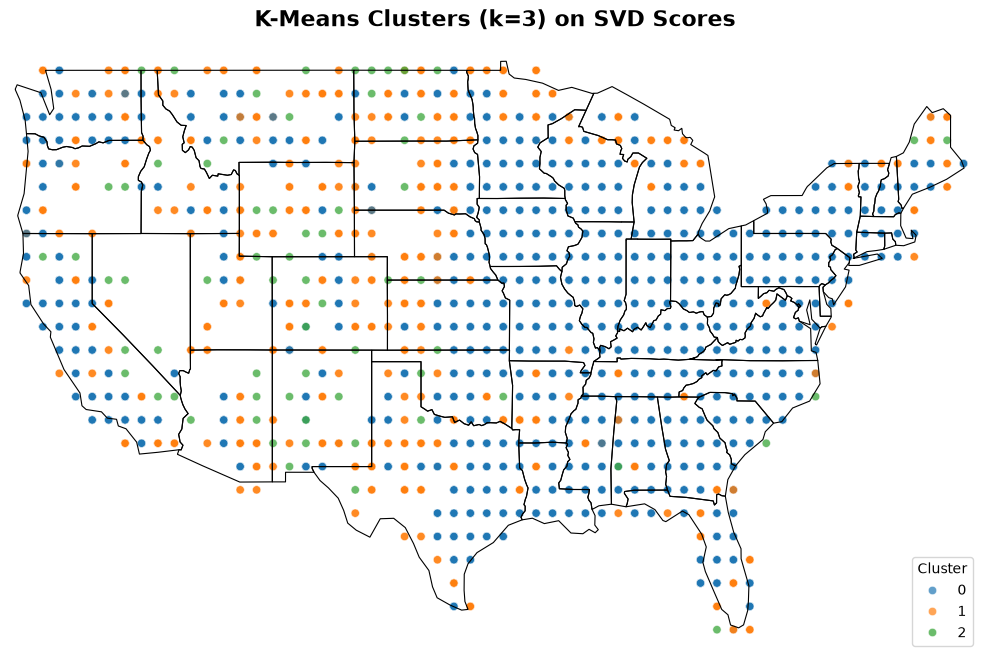

In [ ]:

# 1. Perform k-means clustering as before
kmeans = sk.cluster.KMeans(n_clusters=3, random_state=47)
kmeans.fit(svd_df.drop(columns=['lat', 'long', 'Region', 'STATE']))

# Add cluster labels to the DataFrame
k_means_df = svd_df.copy()
k_means_df['cluster'] = kmeans.labels_

# 2. Filter out Alaska and Hawaii from the scatter data
k_means_df_lower48 = k_means_df[
    (k_means_df['lat'] >= 24) & (k_means_df['lat'] <= 50) &
    (k_means_df['long'] >= -125) & (k_means_df['long'] <= -66)
].copy()

# 3. Filter state boundaries to exclude Alaska and Hawaii
state_gdf = gpd.GeoDataFrame(state_df)
if 'NAME' in state_gdf.columns:
    state_gdf = state_gdf[~state_gdf['NAME'].isin(['Alaska', 'Hawaii'])]
elif 'STUSPS' in state_gdf.columns:
    state_gdf = state_gdf[~state_gdf['STUSPS'].isin(['AK', 'HI'])]

# 4. Plot the clusters
fig, ax = plt.subplots(figsize=(10, 8))

# Plot state boundaries
state_gdf.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.8
)

# Plot scatter points for Lower 48
sns.scatterplot(
    data=k_means_df_lower48,
    x='long',
    y='lat',
    hue='cluster',
    palette='tab10',
    alpha=0.7,
    ax=ax
)

# 5. Lock axis limits to Lower 48 and remove frame for a clean presentation
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.axis('off')

plt.title("K-Means Clusters (k=3) on SVD Scores", fontsize=16, fontweight='bold', pad=15)
plt.legend(title="Cluster", loc="lower right", frameon=True)
plt.tight_layout()
plt.savefig('../figs/kmeans_clusters_map.png', dpi=300, bbox_inches='tight')

In [ ]:
# 1. Perform k-means clustering as before
kmeans = sk.cluster.KMeans(n_clusters=3, random_state=47)
kmeans.fit(svd_df.drop(columns=['lat', 'long', 'Region', 'STATE']))

# Add cluster labels to the DataFrame
k_means_df = svd_df.copy()
k_means_df['cluster'] = kmeans.labels_

# 2. Filter out Alaska and Hawaii from the scatter data
k_means_df_lower48 = k_means_df[
    (k_means_df['lat'] >= 24) & (k_means_df['lat'] <= 50) &
    (k_means_df['long'] >= -125) & (k_means_df['long'] <= -66)
].copy()

# 3. Filter state boundaries to exclude Alaska and Hawaii
state_gdf = gpd.GeoDataFrame(state_df)
if 'NAME' in state_gdf.columns:
    state_gdf = state_gdf[~state_gdf['NAME'].isin(['Alaska', 'Hawaii'])]
elif 'STUSPS' in state_gdf.columns:
    state_gdf = state_gdf[~state_gdf['STUSPS'].isin(['AK', 'HI'])]

# 4. Plot the clusters
fig, ax = plt.subplots(figsize=(10, 8))

# Plot state boundaries
state_gdf.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.8
)

# Plot scatter points for Lower 48
sns.scatterplot(
    data=k_means_df_lower48,
    x='long',
    y='lat',
    hue='cluster',
    palette='tab10',
    alpha=0.7,
    ax=ax
)

# 5. Lock axis limits to Lower 48 and remove frame for a clean presentation
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.axis('off')

plt.title("K-Means Clusters (k=3) on SVD Scores", fontsize=16, fontweight='bold', pad=15)
plt.legend(title="Cluster", loc="lower right", frameon=True)
plt.tight_layout()
plt.savefig('../figs/kmeans_clusters_map.png', dpi=300, bbox_inches='tight')

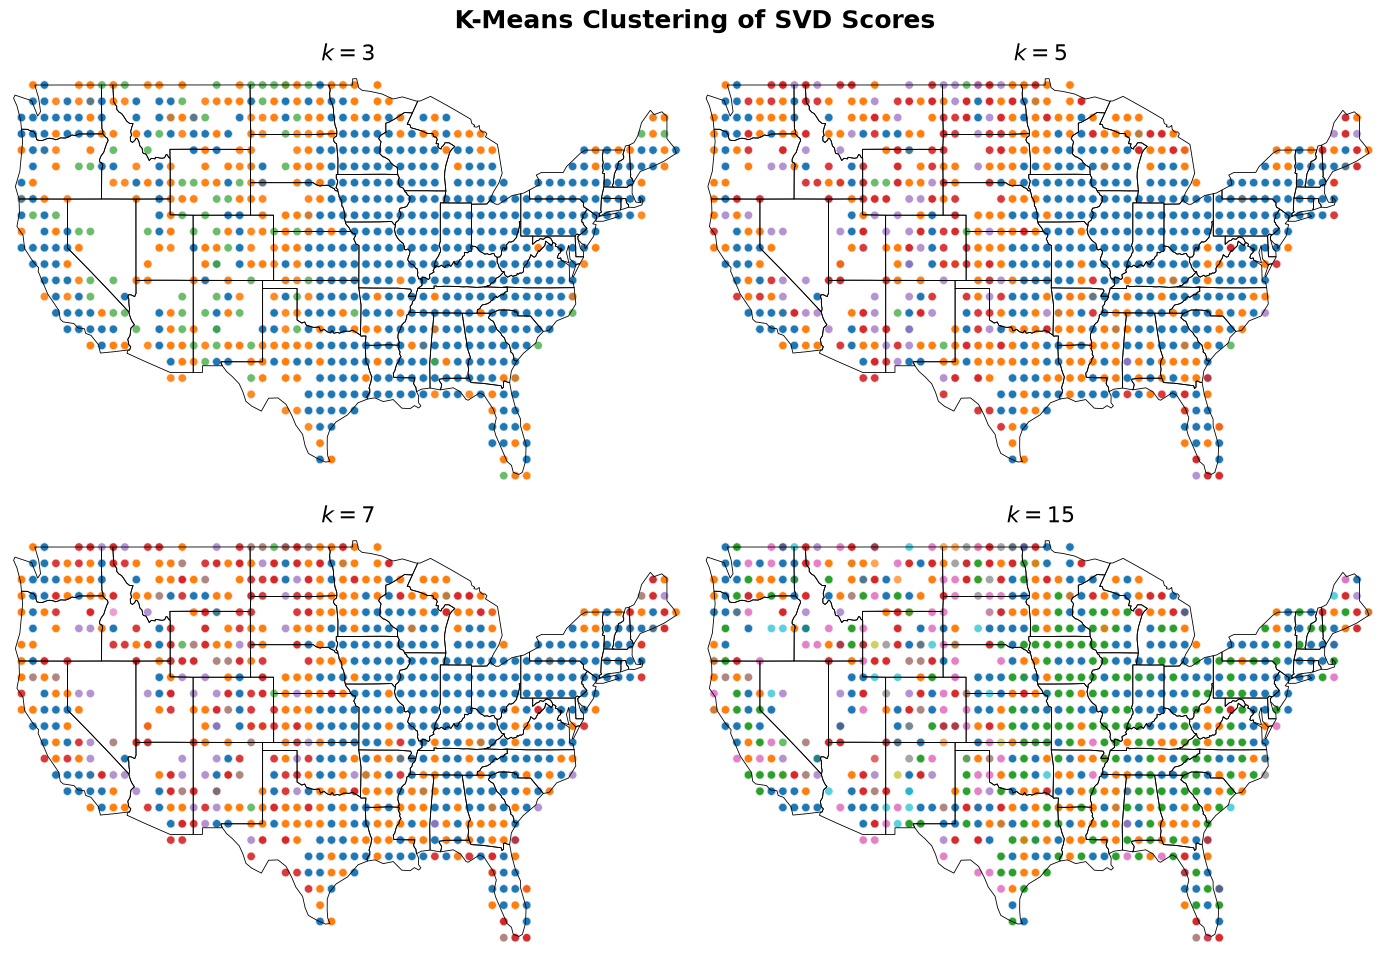

In [ ]:
# K values to compare
k_values = [3, 5, 7, 9]

# Create 2x2 grid
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

axes = axes.flatten()

for ax, k in zip(axes, k_values):

    # Perform K-means
    kmeans = sk.cluster.KMeans(
        n_clusters=k,
        random_state=47
    )

    kmeans.fit(
        svd_df.drop(columns=['lat', 'long', 'Region', 'STATE'])
    )

    # Add cluster labels
    k_means_df = svd_df.copy()
    k_means_df['cluster'] = kmeans.labels_

    # Filter to Lower 48
    k_means_df_lower48 = k_means_df[
        (k_means_df['lat'] >= 24) & 
        (k_means_df['lat'] <= 50) &
        (k_means_df['long'] >= -125) & 
        (k_means_df['long'] <= -66)
    ].copy()

    # Plot state boundaries
    state_gdf.boundary.plot(
        ax=ax,
        color='black',
        linewidth=0.6
    )

    # Plot clusters
    sns.scatterplot(
        data=k_means_df_lower48,
        x='long',
        y='lat',
        hue='cluster',
        palette='tab10',
        alpha=0.7,
        ax=ax,
        legend=False
    )

    # Map limits
    ax.set_xlim(-125, -66)
    ax.set_ylim(24, 50)
    ax.axis('off')

    # Panel title
    ax.set_title(
        f"$k={k}$",
        fontsize=16,
        fontweight='bold'
    )

fig.suptitle(
    "K-Means Clustering of SVD Scores",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '../figs/kmeans_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

#save the plot 
plt.savefig('../figs/kmeans_comparison.png', dpi=300, bbox_inches='tight')

In [ ]:
state_cluster_df.head()

,SVD_1,SVD_2,SVD_3,SVD_4,SVD_5,SVD_6,SVD_7,SVD_8,SVD_9,SVD_10,...,SVD_49,SVD_50,lat,long,Region,STATE,cluster,majority_answer,name,iso_a2
0,0.001153,-0.000008,0.000223,0.000127,0.000148,0.000394,-0.000232,0.000063,-0.000147,-0.000199,...,0.000007,0.000063,44.0,-116.0,Mountain,ID,0,0,NaN,NaN
1,0.000145,-0.000009,-0.000010,-0.000035,0.000034,-0.000010,0.000020,-0.000009,-0.000007,-0.000019,...,0.000017,0.000010,42.0,-73.0,New England,MA,0,0,NaN,NaN
2,0.001095,-0.000046,-0.000006,-0.000097,0.000435,-0.000126,0.000018,0.000056,-0.000264,0.000226,...,-0.000081,0.000083,44.0,-73.0,New England,VT,0,0,NaN,NaN
3,0.000316,-0.000007,-0.000074,-0.000021,0.000109,0.000021,-0.000083,0.000003,0.000009,-0.000049,...,0.000021,0.000006,41.0,-75.0,East Coast,PA,0,0,NaN,NaN
4,0.000084,0.000002,-0.000020,-0.000026,0.000017,-0.000011,-0.000005,0.000008,-0.000018,-0.000013,...,0.000001,-0.000009,42.0,-71.0,New England,MA,0,0,NaN,NaN


## Agglomerative

<Axes: xlabel='long', ylabel='lat'>

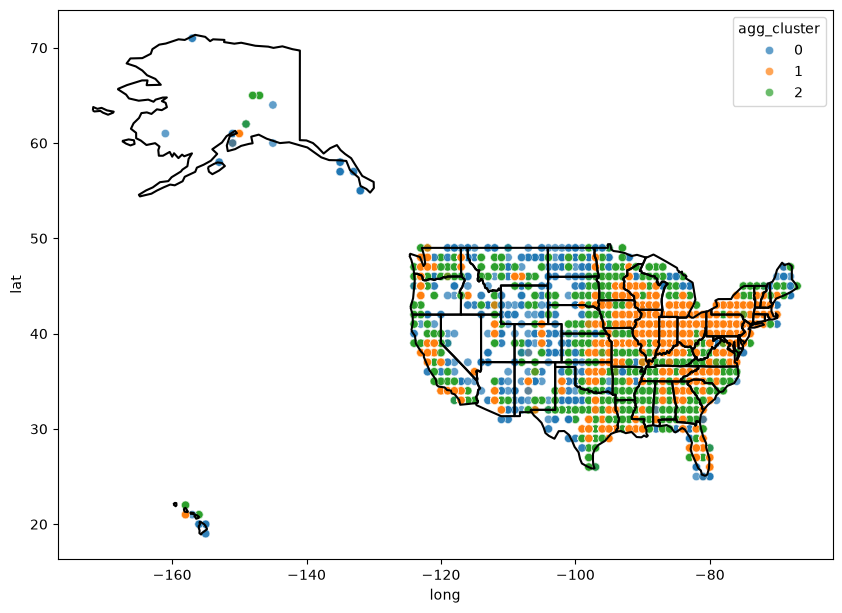

In [ ]:
# perform agglomertive cluserting using non-standardized svd scores
agg_cluster =sk.cluster.AgglomerativeClustering(n_clusters=3).fit(svd_df.drop(columns=['lat', 'long', 'Region']))

agg_df = svd_df.copy()
agg_df['cluster'] = agg_cluster.labels_

plt.figure(figsize=(10, 8))



scatter = sns.scatterplot(
    data=agg_df,
    x='long',
    y='lat',
    hue='cluster',
    palette='tab10',
    alpha=0.7
)
state_gdf = gpd.GeoDataFrame(state_df)
state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black'
)   


<Axes: xlabel='long', ylabel='lat'>

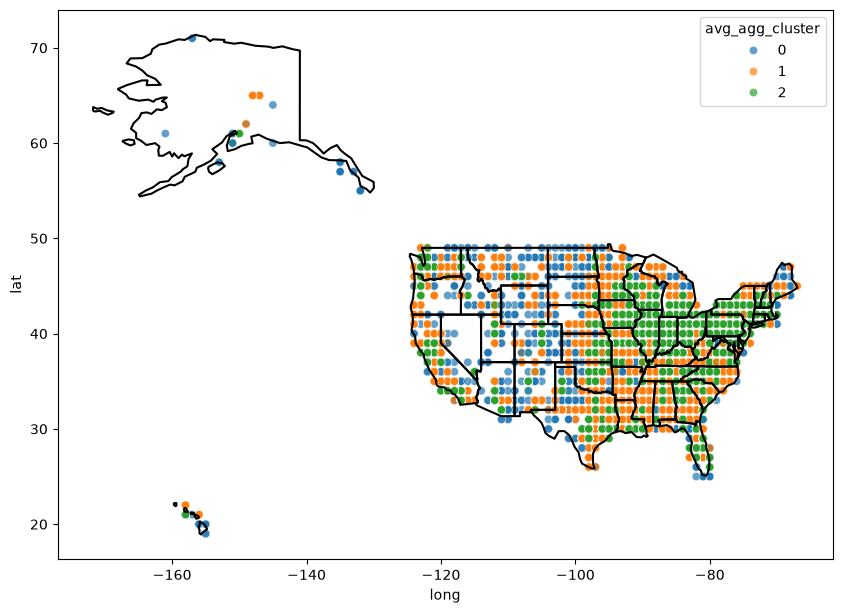

In [ ]:
agg_cluster =sk.cluster.AgglomerativeClustering(n_clusters=3, linkage = 'average').fit(svd_df.drop(columns=['lat', 'long', 'Region']))

avg_agg_df = svd_df.copy()
avg_agg_df['cluster'] = agg_cluster.labels_

plt.figure(figsize=(10, 8))

scatter = sns.scatterplot(
    data=svd_df,
    x='long',
    y='lat',
    hue='avg_agg_cluster',
    palette='tab10',
    alpha=0.7
)
state_gdf = gpd.GeoDataFrame(state_df)
state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black'
)   

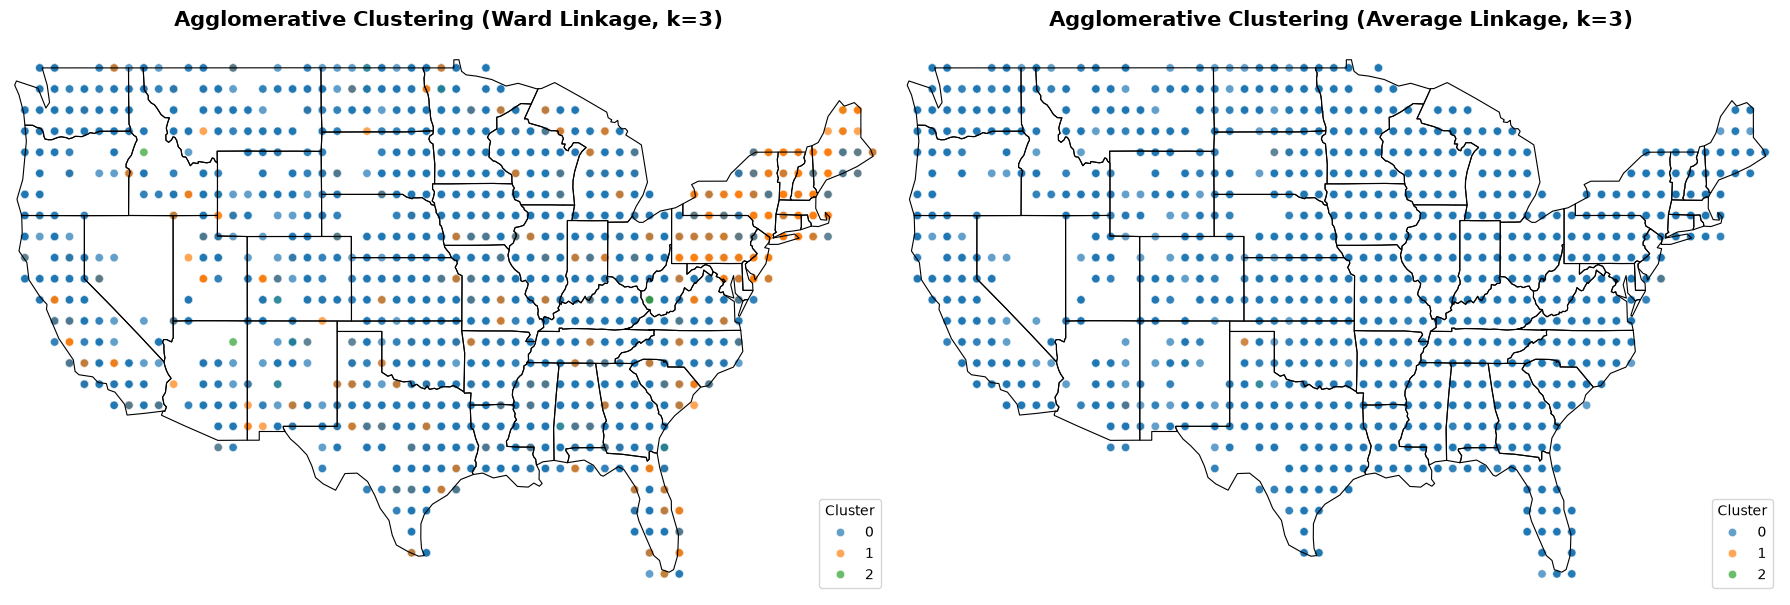

In [ ]:


# Drop metadata/spatial columns for clustering
features = svd_df.drop(columns=['lat', 'long', 'Region', 'STATE'], errors='ignore')

# 1. Default Agglomerative Clustering (Ward Linkage, k=3)
agg_default = sk.cluster.AgglomerativeClustering(n_clusters=3).fit(features)
agg_df = svd_df.copy()
agg_df['cluster'] = agg_default.labels_

# 2. Average Linkage Agglomerative Clustering (k=3)
agg_avg = sk.cluster.AgglomerativeClustering(n_clusters=3, linkage='average').fit(features)
avg_agg_df = svd_df.copy()
avg_agg_df['cluster'] = agg_avg.labels_

# ==========================================
# FILTER ALASKA & HAWAII
# ==========================================
# Filter points to Contiguous US bounding box
agg_df_lower48 = agg_df[
    (agg_df['lat'] >= 24) & (agg_df['lat'] <= 50) &
    (agg_df['long'] >= -125) & (agg_df['long'] <= -66)
].copy()

avg_agg_df_lower48 = avg_agg_df[
    (avg_agg_df['lat'] >= 24) & (avg_agg_df['lat'] <= 50) &
    (avg_agg_df['long'] >= -125) & (avg_agg_df['long'] <= -66)
].copy()

# Filter state boundaries
state_gdf = gpd.GeoDataFrame(state_df)
if 'NAME' in state_gdf.columns:
    state_gdf = state_gdf[~state_gdf['NAME'].isin(['Alaska', 'Hawaii'])]
elif 'STUSPS' in state_gdf.columns:
    state_gdf = state_gdf[~state_gdf['STUSPS'].isin(['AK', 'HI'])]

# ==========================================
# COMBINED SUBPLOT GRID (1 Row, 2 Columns)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- LEFT SUBPLOT: Default Agglomerative (Ward) ---
state_gdf.boundary.plot(ax=ax1, color='black', linewidth=0.8)
sns.scatterplot(
    data=agg_df_lower48,
    x='long',
    y='lat',
    hue='cluster',
    palette='tab10',
    alpha=0.7,
    ax=ax1
)
ax1.set_xlim(-125, -66)
ax1.set_ylim(24, 50)
ax1.axis('off')
ax1.set_title('Agglomerative Clustering (Ward Linkage, k=3)', fontsize=15, fontweight='bold', pad=15)
ax1.legend(title="Cluster", loc="lower right", frameon=True)

# --- RIGHT SUBPLOT: Average Linkage ---
state_gdf.boundary.plot(ax=ax2, color='black', linewidth=0.8)
sns.scatterplot(
    data=avg_agg_df_lower48,
    x='long',
    y='lat',
    hue='cluster',
    palette='tab10',
    alpha=0.7,
    ax=ax2
)
ax2.set_xlim(-125, -66)
ax2.set_ylim(24, 50)
ax2.axis('off')
ax2.set_title('Agglomerative Clustering (Average Linkage, k=3)', fontsize=15, fontweight='bold', pad=15)
ax2.legend(title="Cluster", loc="lower right", frameon=True)

plt.tight_layout()
# save combined plot
plt.savefig('../figs/agglomerative_clustering_map.png', dpi=300, bbox_inches='tight')


## K-means with standarized svd (PCA)

<Axes: xlabel='long', ylabel='lat'>

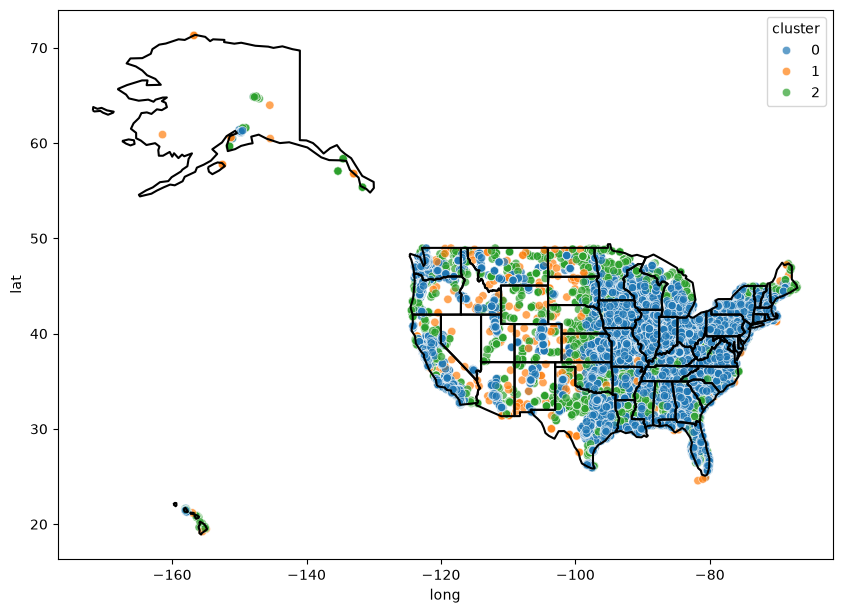

In [ ]:




kmeans.fit(df_standardized_pca.drop(columns=['lat', 'long', 'Region']))

# Add cluster labels to the svd_df and plot on map
k_means_standardized_df = df_standardized_pca.copy()
k_means_standardized_df['cluster'] = kmeans.labels_

# Plot the clusters on a map
plt.figure(figsize=(10, 8))

scatter = sns.scatterplot(
    data=k_means_standardized_df,
    x='long',
    y='lat',
    hue='cluster',
    palette='tab10',
    alpha=0.7
)
state_gdf = gpd.GeoDataFrame(state_df)
state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black'
)   


<Axes: xlabel='long', ylabel='lat'>

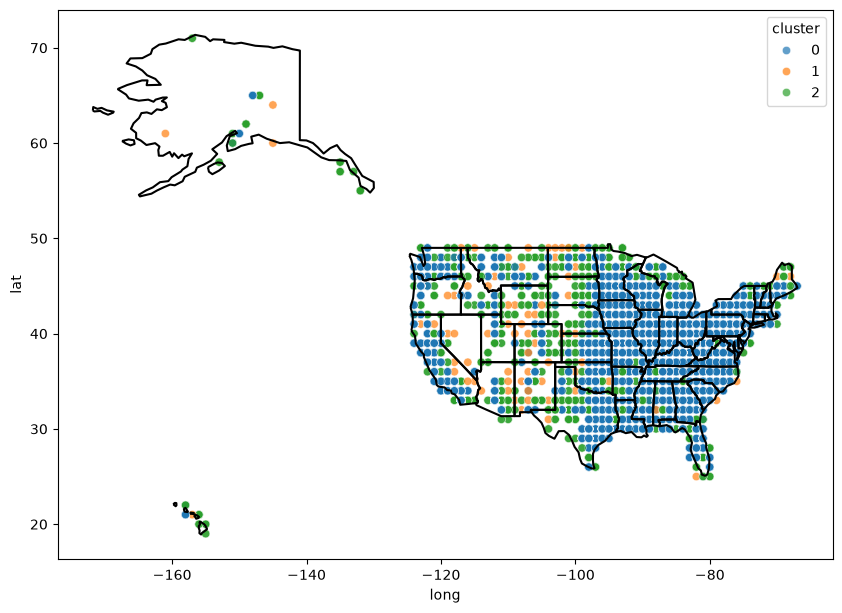

In [ ]:
# Try k-means with full dataset
kmeans = sk.cluster.KMeans(n_clusters= 3, random_state=47)

kmeans.fit(df.drop(columns=metadata_cols))

# Add cluster labels to the svd_df and plot on map
k_means_full_df = svd_df.copy()
k_means_full_df['cluster'] = kmeans.labels_

# Plot the clusters on a map
plt.figure(figsize=(10, 8))

scatter = sns.scatterplot(
    data=k_means_full_df,
    x='long',
    y='lat',
    hue='cluster',
    palette='tab10',
    alpha=0.7
)
state_gdf = gpd.GeoDataFrame(state_df)
state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black'
)   




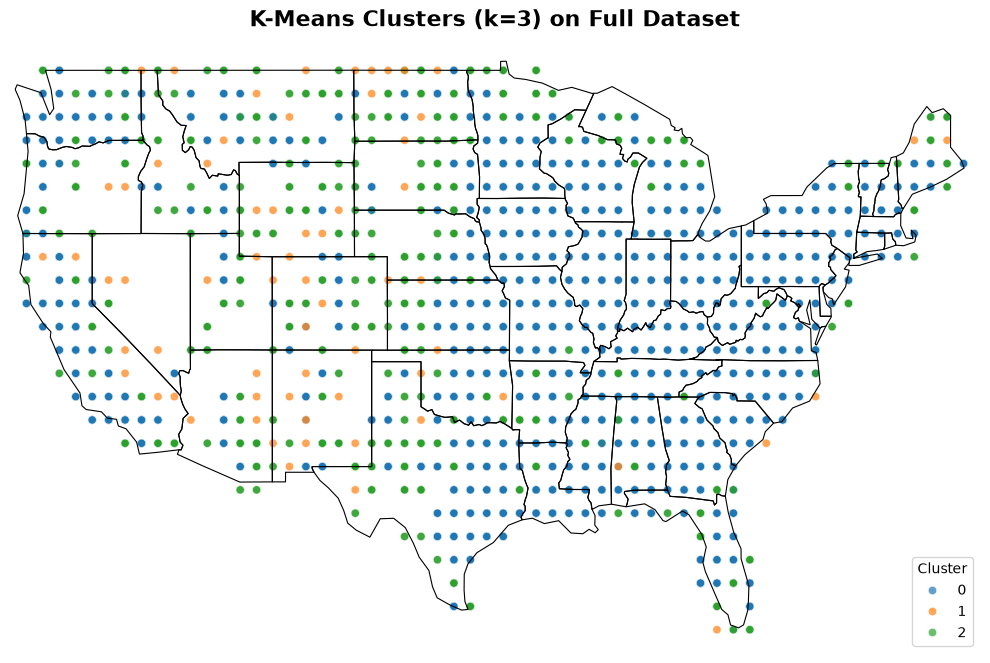

In [ ]:


# 1. Fit K-Means on full dataset
kmeans = sk.cluster.KMeans(n_clusters=3, random_state=47)
kmeans.fit(df.drop(columns=metadata_cols, errors='ignore'))

# Add cluster labels to the dataframe
k_means_full_df = svd_df.copy()
k_means_full_df['cluster'] = kmeans.labels_

# 2. Filter out Alaska and Hawaii from the scatter points (Lower 48 bounding box)
k_means_full_lower48 = k_means_full_df[
    (k_means_full_df['lat'] >= 24) & (k_means_full_df['lat'] <= 50) &
    (k_means_full_df['long'] >= -125) & (k_means_full_df['long'] <= -66)
].copy()

# 3. Filter state boundaries to exclude Alaska and Hawaii
state_gdf = gpd.GeoDataFrame(state_df)
if 'NAME' in state_gdf.columns:
    state_gdf = state_gdf[~state_gdf['NAME'].isin(['Alaska', 'Hawaii'])]
elif 'STUSPS' in state_gdf.columns:
    state_gdf = state_gdf[~state_gdf['STUSPS'].isin(['AK', 'HI'])]

# 4. Plot the map
fig, ax = plt.subplots(figsize=(10, 8))

# Plot state boundaries
state_gdf.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.8
)

# Plot scatter points for Lower 48
sns.scatterplot(
    data=k_means_full_lower48,
    x='long',
    y='lat',
    hue='cluster',
    palette='tab10',
    alpha=0.7,
    ax=ax
)

# 5. Lock axis limits to Lower 48 view
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.axis('off')

plt.title("K-Means Clusters (k=3) on Full Dataset", fontsize=16, fontweight='bold', pad=15)
plt.legend(title="Cluster", loc="lower right", frameon=True)
plt.tight_layout()
# save 
plt.savefig('../figs/kmeans_full_dataset_map.png', dpi=300, bbox_inches='tight')

In [ ]:
svd_df.head()

,SVD_1,SVD_2,SVD_3,SVD_4,SVD_5,SVD_6,SVD_7,SVD_8,SVD_9,SVD_10,...,SVD_22,SVD_23,SVD_24,SVD_25,lat,long,Region,cluster,agg_cluster,avg_agg_cluster
0,0.001153,-0.000008,0.000223,0.000127,0.000148,0.000394,-0.000232,0.000063,-0.000146,-0.000198,...,0.000083,-0.000027,0.000134,-0.000133,44.0,-116.0,Mountain,0,1,2
1,0.000145,-0.000009,-0.000010,-0.000035,0.000034,-0.000010,0.000020,-0.000009,-0.000007,-0.000019,...,-0.000031,-0.000014,0.000016,-0.000010,42.0,-73.0,New England,0,1,2
2,0.001095,-0.000046,-0.000006,-0.000097,0.000435,-0.000126,0.000019,0.000057,-0.000265,0.000226,...,-0.000101,0.000003,-0.000081,0.000193,44.0,-73.0,New England,0,1,2
3,0.000316,-0.000007,-0.000074,-0.000021,0.000109,0.000021,-0.000083,0.000003,0.000008,-0.000049,...,0.000021,0.000021,-0.000023,-0.000012,41.0,-75.0,East Coast,0,1,2
4,0.000084,0.000002,-0.000020,-0.000026,0.000017,-0.000011,-0.000005,0.000008,-0.000018,-0.000013,...,0.000003,-0.000008,0.000019,0.000013,42.0,-71.0,New England,0,1,2
